In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from collections import defaultdict
import scienceplots

# plt.style.use(["nature"])
# Nature
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 2. Tell the math engine to use custom fonts instead of LaTeX fonts
plt.rcParams['mathtext.fontset'] = 'custom'

# 3. Assign Arial to the standard math modes (for numbers and variables inside $...$)
plt.rcParams['mathtext.rm'] = 'Arial'         # Roman (normal) math text
plt.rcParams['mathtext.it'] = 'Arial:italic'  # Italic math text
plt.rcParams['mathtext.bf'] = 'Arial:bold'    # Bold math text
# plt.rcParams['pdf.fonttype'] = 42               # can't do this here because it doesn't handle vectors
# plt.rcParams['ps.fonttype'] = 42  # Do the same if you ever save to .eps

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
V1064Er = 15.            # 1064 lattice depth, in 1064 recoil energy
V532Er = 0.             # 532 lattice depth, in 532 recoil energy
# Rb kHz to Er
# V1064Er = 20. / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0. / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = np.pi*1/3, -np.pi*1/3    # decorated triangular lattice (2/3 also works)
# phi12, phi23 = np.pi*4e-3, -np.pi*4e-3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 6             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 4         # inclusive
# qverts_str = 'np.array([0.4, -0.4]), np.array([0.4, 0.4]), np.array([-0.4, 0.4]), np.array([-0.4, -0.4]), np.array([0.4, -0.4])'
# qverts_str = 'E9c.Kp4/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'
# x_ticklist = ["K'", '$\Gamma$', 'K', 'M', '$\Gamma$']
qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$']
save_results = False

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

In [5]:
def MinimumGap(e_values, band1, band2):
    """Prints the position and energy of the minimum gap.
    
    Example: MinimumGap(e_values,2,3)
    Should be slightly enhanced to return something
    """
    gaps = e_values[:, band2] - e_values[:, band1]
    print('The minimum band gap between band{} and band{} is {} kHz, happening at the {} (python index) q evaluated' \
          .format(band1, band2, gaps.min() * f_unit / 1e3 / (2 * np.pi), gaps.argmin()))

# Real space plots

Pretty sure that the orientation is still wrong - maybe flipped about $x = 0$?

In [6]:
bool_plot_real = False
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6

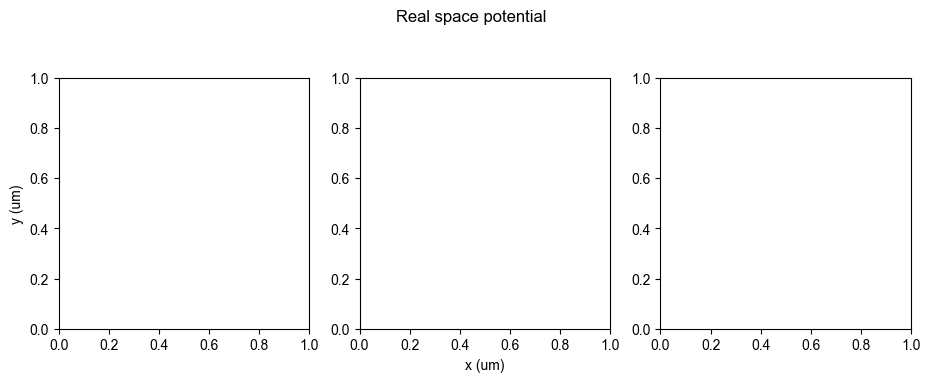

In [7]:
pos_delta = E9c.a_lw_hex * E9c.k1k * (phi12 / 2 / np.pi) + E9c.a_lw_hex * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real
fig_real = plt.figure(figsize = (11, 4))
ax_532 = fig_real.add_subplot(131, aspect = "equal")
ax_1064 = fig_real.add_subplot(132, aspect = "equal")
ax_super = fig_real.add_subplot(133, aspect = "equal")
fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")
if bool_plot_real:
    for ax, V_real, ax_title in zip([ax_532, ax_1064, ax_super],
                                    [V_532_real, V_1064_real, V_super_real],
                                    ["532 nm", "1064 nm", "Combined"],):
        alpha = V_real / np.nanmax(V_real)
        im = ax.pcolormesh(x_real, y_real, V_real, cmap = 'viridis')
        ax.scatter(0, 0, color = 'red', marker = '+', s = 50)
        ax.set_title(ax_title)
        # fig_real.colorbar(im, ax = ax)
    

# Finding Bloch states and band energies

In [8]:
dq = 0.01
rq_circ = 0.6

Total number of points = 234
--- 3.6856980323791504 seconds ---


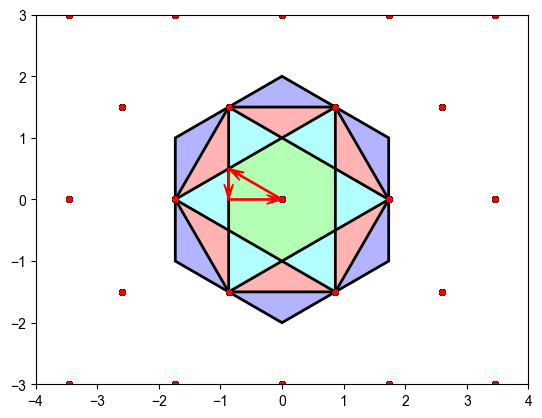

In [9]:
start_time = time.time()

# Generate qset

# Piecewise linear
# number of points sampled between two points (can be an array specifying each path, or just one number for all)
num_points = np.array([int(np.linalg.norm(p2 - p1) / dq) for p1, p2 in zip(qverts_arr[:-1], qverts_arr[1:])])
index_points = np.hstack((np.array([0]), np.cumsum(num_points))) - np.arange(len(num_points) + 1)
qsets, xq = bsc.find_qset_piecewise_linear(qverts_arr, num_points)
PlotBZinput = qverts_str

e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

# find non-interacting solution
print("Total number of points = {0}".format(len(qsets)))
fig_BZ, ax_BZ = plt.subplots(1, 1)#, figsize = (20, 16))
bsc.PlotBZSubplot(ax_BZ)
bsc.plot_qset(ax_BZ, qset = PlotBZinput)
Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)

    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))

e_states_fixed = bsc.fix_gauge_parallel_transport_1d(e_states)
print("--- {0} seconds ---".format((time.time() - start_time)))

In [10]:
if not np.all(np.isreal(e_values)):
    logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
e_values = e_values.astype(np.double)

C:\Users\ken92\AppData\Local\Temp\ipykernel_14256\1078986975.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  e_values = e_values.astype(np.double)


## Plots

In [11]:
str_journal = "BIGGUS"  # for screen display
str_journal = "nature"

### Band structure

In [12]:
f_kHz_PM_12 = np.array([3., 3.])
f_kHz_PM_13 = np.array([7.75, 12.4])
f_kHz_PM_14 = np.array([12.6, 16.1])
f_kHz_res = 1.

band_colors = E9c.BZcolor_black
color_PM_12 = E9c.BZcolor_science[2]#"#E1A20E"
color_PM_13 = E9c.BZcolor_science[3]#"#27E10E"
color_PM_14 = E9c.BZcolor_science[4]#"#E14A0E"

In [13]:
mm2inch = 1 / 25.4
plt_sizes_all_journals = {
    "nature": {
        "fig_E_figsize":    np.array([60, 45]) * mm2inch,

        "band_lw":          1,
        "PM_12_lw":         0.5,

        "alpha_fill_cnst":  0.8,
        "alpha_fill_grad":  0.5,
        
        "tick_size":        2,
        "tick_width":       0.3,
        "xtick_fontsize":   7,
        "ytick_fontsize":   6,
        "ylabel_fontsize":  7,
    },
    "BIGGUS": {
        "fig_E_figsize":    np.array([8, 6]),

        "band_lw":          3,
        "PM_12_lw":         2,

        "alpha_fill_cnst":  0.8,
        "alpha_fill_grad":  0.8,
        
        "tick_size":        4,
        "tick_width":       1.5,
        "xtick_fontsize":   28,
        "ytick_fontsize":   26,
        "ylabel_fontsize":  28,
    }
}

plt_sizes = plt_sizes_all_journals[str_journal]

For nature submission


INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern


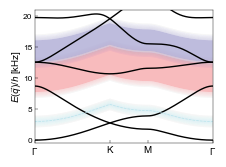

In [ ]:
print(f"For {str_journal} submission")

f2kHz = f_unit / 1e3 / (2 * np.pi) # conversion factor from natural units to kHz
E_lowest = np.min(e_values)
E_kHz_offset = (e_values - E_lowest) * f2kHz
E_kHz_highest = np.max(E_kHz_offset)
E_plot_kHz = (e_values.transpose() - E_lowest) * f2kHz

fig_E, ax_E = plt.subplots(1, 1, figsize = plt_sizes["fig_E_figsize"])
for i in range(bandnum):
    ax_E.plot(xq, E_plot_kHz[i], '-', label = 'Non-interacting' + str(i + bandstart),
              color = band_colors[i + 1], lw = plt_sizes["band_lw"])

# ticks and labels
ax_E.tick_params(axis = 'both', direction = "in", size = plt_sizes["tick_size"], width = plt_sizes["tick_width"], pad = 2)
ax_E.set_xticks(xq[index_points], x_ticklist, fontsize = plt_sizes["xtick_fontsize"])
ax_E.set_yticks([0, 5, 10, 15, 20], [0, 5, 10, 15, 20], fontsize = plt_sizes["ytick_fontsize"])
ax_E.set_ylabel(r'$E(\vec{q})/h$ [kHz]', fontsize = plt_sizes["ylabel_fontsize"], labelpad = -1)

# plot lims
ax_E.set_xlim(xq[0], xq[-1])
ax_E.set_ylim(-0.5, 21)

# Add shades for the range of excitation addressed
ax_E.plot(xq, E_plot_kHz[0] + f_kHz_PM_12[0], '--', color = color_PM_12, lw = plt_sizes["PM_12_lw"])
for f_kHz_PM, color in zip([f_kHz_PM_12, f_kHz_PM_13, f_kHz_PM_14], [color_PM_12, color_PM_13, color_PM_14]):
    ax_E.fill_between(xq, E_plot_kHz[0] + f_kHz_PM[0], E_plot_kHz[0] + f_kHz_PM[1],
                    color = color, alpha = plt_sizes["alpha_fill_cnst"], edgecolor = "none")
    util.fill_between_ygradient(ax_E, xq, E_plot_kHz[0] + f_kHz_PM[0], E_plot_kHz[0] + f_kHz_PM[0] - f_kHz_res,
                                color1 = to_rgba(color, alpha = plt_sizes["alpha_fill_grad"]), color2 = to_rgba(color, alpha = 0))
    util.fill_between_ygradient(ax_E, xq, E_plot_kHz[0] + f_kHz_PM[1], E_plot_kHz[0] + f_kHz_PM[1] + f_kHz_res,
                                color1 = to_rgba(color, alpha = plt_sizes["alpha_fill_grad"]), color2 = to_rgba(color, alpha = 0))

for spine in ax_E.spines.values():
    spine.set_linewidth(0.3)

# fig_E.suptitle(f'1D q-trajectory, {species}')
fig_E.tight_layout()
fig1apath = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig1",
                 f"fig1a_{str_journal}.pdf")
# fig_E.savefig(fig1apath, format = "pdf", facecolor = "none", dpi = 300)

In [15]:
raise(Exception("nah"))

Exception: nah

## Bloch state
### Population in each peak
I use the ground state to visualize the peak that I'm looking at.

In [ ]:
color_B12 = np.array([1, 0, 0])      # Colors in an array of [R, G, B] for easier numerical manipulation
color_B23 = np.array([0, 1, 0])
color_B13 = np.array([0, 0, 1])
color_center = np.array([0, 0, 0])
color_else = np.array([0, 0, 0])
# This is arranged in the order of [G1, G2, G3]
all_colors = np.vstack([color_B23, color_B13, color_B12])

dict_diff_order = {
    "center": np.array([0, 0, 0]),
    "G1_1st": np.array([1, 0, 0]),
    "G2_1st": np.array([0, 1, 0]),
    "G3_1st": np.array([0, 0, 1]),
    "G1_2nd": np.array([2, 0, 0]),
    "G2_2nd": np.array([0, 2, 0]),
    "G3_2nd": np.array([0, 0, 2]),
    "G1_G2": np.array([1, -1, 0]),  # This is G1_1st - G2_1st; other pairs follows similarly
    "G2_G3": np.array([0, 1, -1]),
    "G3_G1": np.array([-1, 0, 1]),
}

hw_mn = np.array([E9c.k_lw * 0.3, E9c.k_lw * 0.3])    # half width of the box that encloses each peak

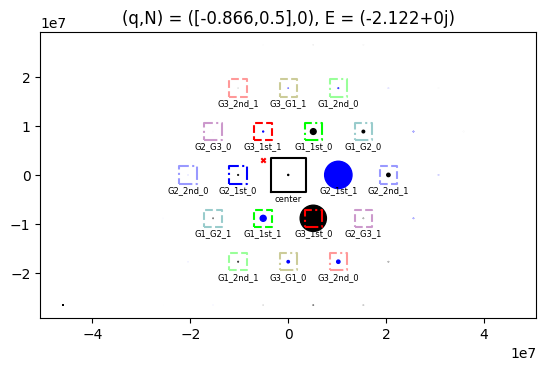

In [ ]:
psi_gs = e_states_ni[0][99] # Need to fix this ugly code at some point
dict_color_pairs = {"center": color_center, "everything else": color_else}
ax_gs = bsc.ToFSubplot(psi_gs)

# center peak
util.plot_rectangle(ax_gs, center = psi_gs.q, half_widths = hw_mn * 2,
                    color = color_center, ls = "-")
ax_gs.text(psi_gs.q[0], psi_gs.q[1] - E9c.k_lw * 0.9, 'center',
            fontsize = 6, horizontalalignment = 'center', color = 'k')

# diffraction peaks
for label_pair, diff_order in dict_diff_order.items():
    if label_pair == "center": continue
    m_diff = diff_order[0] - diff_order[2]
    n_diff = diff_order[1] - diff_order[2]

    num_of_diff = abs(diff_order).sum()
    color = abs(diff_order) @ all_colors / num_of_diff
    dict_color_pairs[label_pair] = color
    alpha = 1 - np.sqrt(num_of_diff - 1) * 0.6

    for i_pk, ls_pk in zip([0, 1], ["-.", "--"]):
        vec = ((m_diff * E9c.G1 + psi_gs.q[0]) +
               (n_diff * E9c.G2 + psi_gs.q[1])) * (-1)**i_pk
        util.plot_rectangle(ax_gs, center = vec, half_widths = hw_mn,
                            color = color, alpha = alpha, ls = ls_pk)
        ax_gs.text(vec[0], vec[1] - E9c.k_lw * 0.6, label_pair + f'_{i_pk}',
                   fontsize = 6, horizontalalignment = 'center', color = 'k')

### Visualize a particular Bloch state

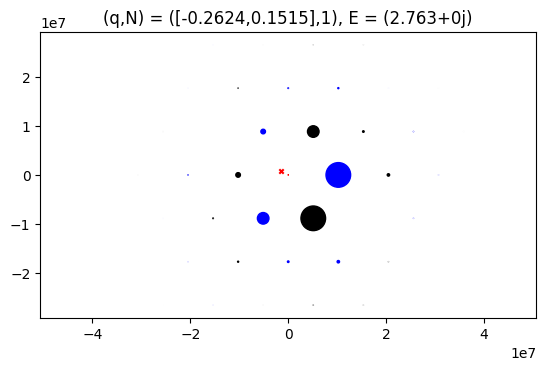

In [ ]:
# ax_ToF = bsc.ToFSubplot(bsc.FindInStateList(e_states_ni[1], E9c.Kp*0.5, 1))
ax_ToF = bsc.ToFSubplot(e_states_ni[1][30])

# Interband Berry conections
I calculate all the connections within the given range of bands.
## Finding $A_{mn}$

In [ ]:
# For example, A_01(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
# To avoidA_10(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
inter_Berry_conns = np.zeros((len(qsets), bandnum, bandnum, 2), dtype = np.float128)

for i in range(len(qsets)):
    for i_lower in range(bandnum):
        for i_higher in range(i_lower + 1, bandnum):
            psi1, psi2 = e_states_fixed[i, :, i_lower], e_states_fixed[i, :, i_higher]
            E12 = e_values[i, i_higher] - e_values[i, i_lower]
            inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)

inter_Berry_conns_mag = np.linalg.norm(inter_Berry_conns, axis = 3)

C:\Users\ken92\AppData\Local\Temp\ipykernel_18404\1270803215.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)
C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\E9_fn\plane_wave_expansion\blochstate_class.py:1009: RuntimeWarning: divide by zero encountered in divide
  return np.einsum('a,abc,b->c', np.conj(psi2), np.stack([delx_H, dely_H], axis = 2), psi1) / E12
C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\E9_fn\plane_wave_expansion\blochstate_class.py:1009: RuntimeWarning: invalid value encountered in divide
  return np.einsum('a,abc,b->c', np.conj(psi2), np.stack([delx_H, dely_H], axis = 2), psi1) / E12


## Plots

In [ ]:
i_Berry = (0, 1)            # The bands between which the A_mn is plotted
alpha_pwr = 1 / 3
quiver_interval = 10

In [ ]:
A_Berry = inter_Berry_conns[:, *i_Berry, :] # Interband Berry connection of the selected bands
A_mag = inter_Berry_conns_mag[:, *i_Berry]  # Magnitude of A_Berry
A_plot = A_Berry / A_mag[:, np.newaxis]     # Normalized A_Berry for the direction plot

A_mag = np.nan_to_num(A_mag, nan = 0., posinf = 1.)
logA_mag = np.log(A_mag)   # note: row = y, col = x

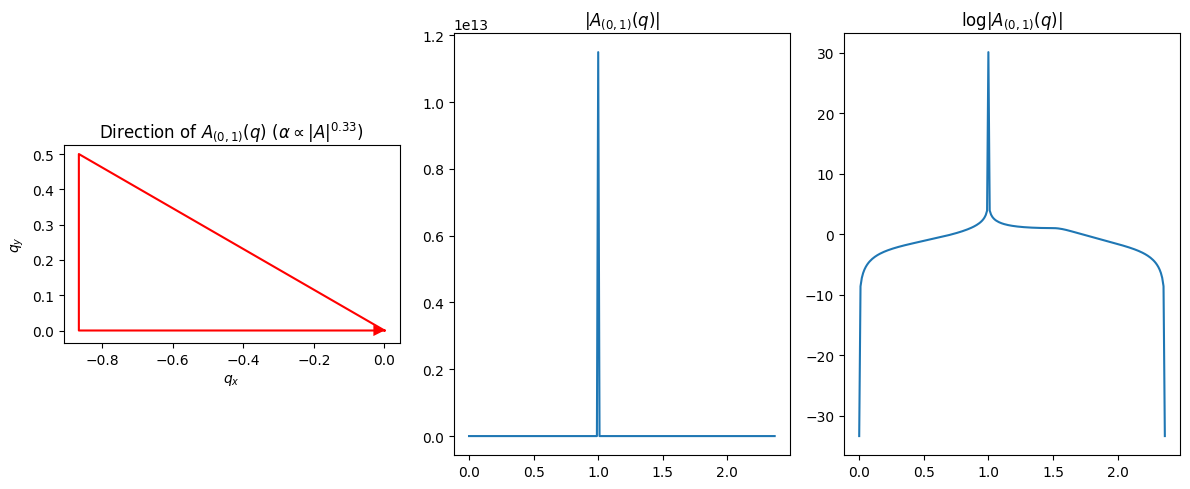

In [ ]:
# Visualize A_01(q) as a vector field over the BZ
fig_Berry, axes_Berry = plt.subplots(1, 3, figsize=(12, 5))

# Normalize magnitudes into [0,1] for alpha
A_mag_finite = A_mag[np.isfinite(A_mag)]
if np.nanmax(A_mag_finite) > 0:
    alpha_vals = np.nan_to_num(A_mag / A_mag_finite.max(), nan = 0., posinf = 1., neginf = 1.)
else:
    alpha_vals = np.zeros_like(A_mag)

# Vector field plots
# Build RGBA colors with alpha = amplitude
base_color = (0.1, 0.2, 0.8)  # e.g. blue-ish
colors_rgba = np.zeros((len(A_mag), 4))
colors_rgba[:, 0] = base_color[0]
colors_rgba[:, 1] = base_color[1]
colors_rgba[:, 2] = base_color[2]
colors_rgba[:, 3] = alpha_vals**alpha_pwr

quiver_scale = dq / 0.02
axes_Berry[0].quiver(
    qsets[::quiver_interval, 0], qsets[::quiver_interval, 1],
    A_plot[::quiver_interval, 0], A_plot[::quiver_interval, 1],
    color = colors_rgba,
    angles = 'xy', scale_units = 'xy', scale = 20 * quiver_scale,
    width = 0.01 * quiver_scale
)
axes_Berry[0].set_title(rf"Direction of $A_{{{i_Berry}}}(q)$ ($\alpha \propto |A|^{{{alpha_pwr:.2f}}}$)")
axes_Berry[0].set_xlabel(r"$q_x$")
axes_Berry[0].set_ylabel(r"$q_y$")
axes_Berry[0].set_aspect('equal')
bsc.plot_qset(axes_Berry[0], qset = qsets, qset_type = 'circle')

# |A| plot
axes_Berry[1].plot(xq, A_mag)
axes_Berry[1].set_title(rf"$|A_{{{i_Berry}}}(q)|$")

# log|A| plot
axes_Berry[2].plot(xq, logA_mag)
axes_Berry[2].set_title(rf"$\log |A_{{{i_Berry}}}(q)|$")

fig_Berry.tight_layout()

## Linear shaking

In [ ]:
# Angles of shaking used in the interband Berry connection paper
# theta_deg_init = -160
# theta_deg_lin_PM = theta_deg_init + 160 * np.linspace(0, 1, num = 9)
theta_deg_lin_PM = 180 * np.linspace(-1, 0, num = 100)    # Angles of shaking
bool_flip_in_y = True   # I think this is needed because of our orientation of camera

ValueError: could not broadcast input array from shape (0,) into shape (4,)

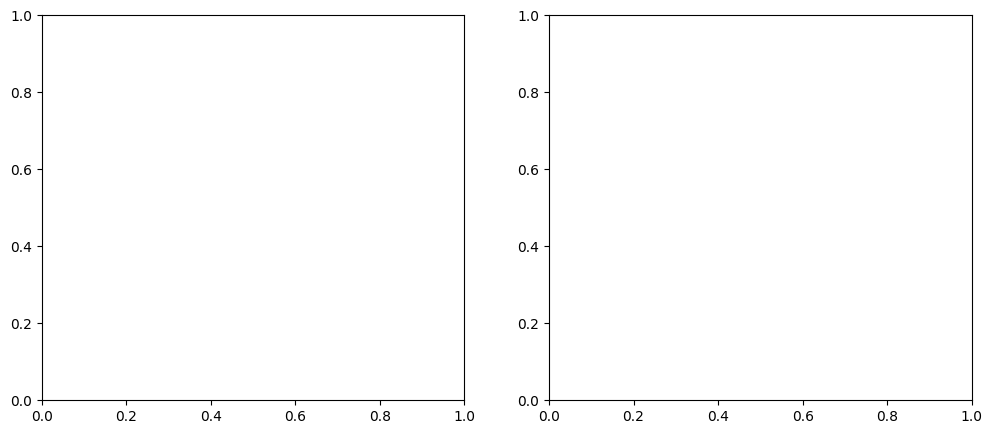

In [ ]:
theta_min_ME = np.full((len(theta_deg_lin_PM), 4), np.nan)                  # This assumes four nodes
theta_deviation = np.full((len(theta_deg_lin_PM), 4), np.nan)               # Deviation from the theory curve
fig_lin_PM, axes_lin_PM = plt.subplots(1, 2, figsize=(12, 5))

theta_xq = np.arctan2(qsets[:,1], qsets[:,0]) *  180 / np.pi
for i, theta in enumerate(theta_deg_lin_PM):
    vec_PM = np.array([np.cos(theta / 180 * np.pi), np.sin(theta / 180 * np.pi) * (-1)**int(bool_flip_in_y)])
    ME2_Fermi = np.abs(A_Berry @ vec_PM)**2     # Proportional to matrix element squared
    ME2_Fermi = np.nan_to_num(ME2_Fermi, nan = 0., posinf = 1.)
    logME2_Fermi = np.log(ME2_Fermi)
    idxs_min = util.find_local_minima(logME2_Fermi, wrap = True)

    theta_min_ME[i, :] = theta_xq[idxs_min]
    ME2_Fermi_offset = ME2_Fermi + 0.3 * i

    color = util.get_color(theta, theta_deg_lin_PM)
    axes_lin_PM[0].plot(theta_xq, ME2_Fermi_offset, color = color, label = f"{theta:.1f}")
    axes_lin_PM[0].scatter(theta_xq[idxs_min], ME2_Fermi_offset[idxs_min], color = color)
    # axes_lin_PM[1].scatter([theta for _ in idxs_min], theta_xq[idxs_min], color = color)

# align the points and match it to experiment convention by hand
idx_phase_jump = int(len(theta_deg_lin_PM) / 2)
theta_min_ME[idx_phase_jump:,:] = np.roll(theta_min_ME[idx_phase_jump:,:], -1, axis = 1)  # to make the top line continuous
theta_min_ME[:, (0,1)] += 360.
theta_min_ME = np.roll(theta_min_ME, 2, axis = 1)
theta_min_ME = np.unwrap(theta_min_ME, axis = 1, period = 360.)

for i in range(4):
    theta_th = theta_deg_lin_PM / 2 + i * 90 + 135
    axes_lin_PM[1].plot(theta_deg_lin_PM, theta_th, ls = "--", color = "grey")
    # axes_lin_PM[1].scatter(theta_deg_lin_PM, theta_min_ME[:, i])
    axes_lin_PM[1].plot(theta_deg_lin_PM, theta_min_ME[:, i])
    theta_deviation[:, i] = ((theta_min_ME[:, i] - theta_th) + 180) % 360 - 180
    
print(f"Maximum deviation from the theory is {theta_deviation.max():.3f} degrees")

# axes_lin_PM[0].legend()
axes_lin_PM[0].set_title(rf"$|A_{{{i_Berry}}}(q) \cdot \epsilon(\theta)|$")
axes_lin_PM[0].set_xlabel()
axes_lin_PM[1].set_title(rf"Position of minima ($r = {rq_circ} q_K$)")
fig_lin_PM.suptitle("Nodal line angular position from plane wave expansion")

In [ ]:
A_node_str = f"node_position_band{i_Berry[0]}{i_Berry[1]}_lw{V1064nom:.2f}kHz_rq{rq_circ}qK.npz"
A_node_save_path = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2", A_node_str)
# print(A_node_save_path)
# np.savez(A_node_save_path, theta_deg_lin_PM = theta_deg_lin_PM, theta_min_ME = theta_min_ME)

C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\node_position_band01_lw39.50kHz_rq0.6qK.np


# Quantum metric tensor (Ignore for now)

In [ ]:
bool_find_QMT = False

In [ ]:
if bool_find_QMT:
    qgts_xx = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
    for i in range(len(qsets)):
        for j in range(bandnum):
            qgts_xx[i, j] = bsc.find_q_geo_tensor(i, j, Exp_lib, qsets, e_values, e_states, Hq_mmat, Hq_nmat)
    qmts_xx = np.real(qgts_xx)                # quantum metric tensor
    berry_curvs_xx = - 2 * np.imag(qgts_xx)   # Berry curvature

    fig_qgt = plt.figure(2, figsize=(10,7))
    fig_qgt.clf()
    ax_qgt = fig_qgt.add_subplot(111)
    ax_qgt.set_title('Quantum geometric tensor')
    ax_qgt.plot(xq, qmts_xx[:, 2], label = 'qmts_00')